In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


pd.set_option("display.max_columns",None)

df=pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")

df.head();



In [6]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 6362620
Columns: 11


In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
df.columns.to_list()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [ ]:
df.isnull().sum()

# No missing values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
dtype: float64

In [ ]:
# Duplicate Analysis

df.duplicated().sum()

# No duplicates

np.int64(0)

In [13]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [15]:
fraud_perct=(df["isFraud"].value_counts(normalize=True)*100)

fraud_perct

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [ ]:
# The proportion of fraud is very less compared to not fraud

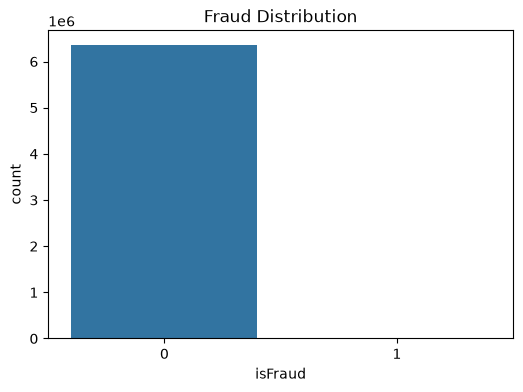

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x="isFraud",data=df)
plt.title("Fraud Distribution")
plt.show()

In [17]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

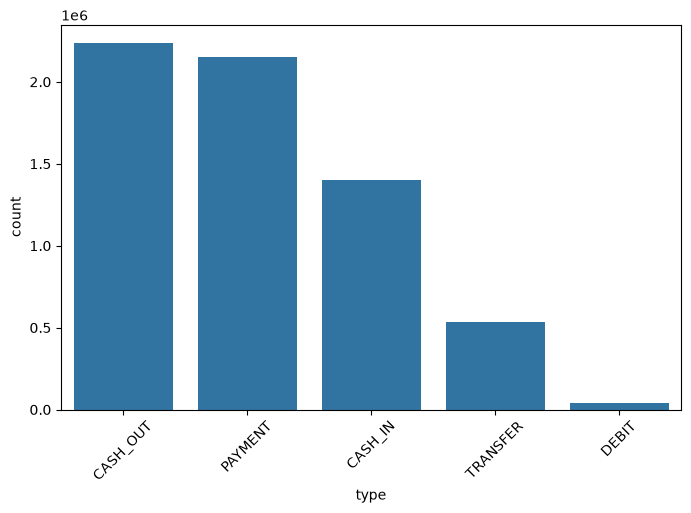

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x="type",data=df,order=df["type"].value_counts().index)

plt.xticks(rotation=45)
plt.show()

In [19]:
# Cash_out is most common among all types


In [20]:
pd.crosstab(df['type'],df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [21]:
# Cash out and transaction are most common fraud techniques type

In [22]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
)*100

fraud_by_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


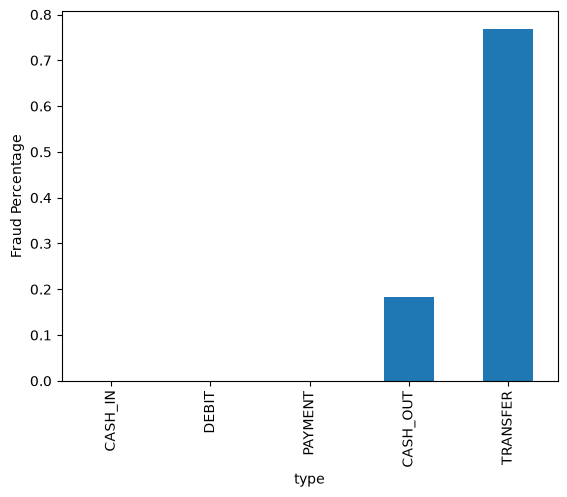

In [23]:
fraud_by_type[1].sort_values().plot(
    kind="bar"
)

plt.ylabel("Fraud Percentage")
plt.show()

In [24]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

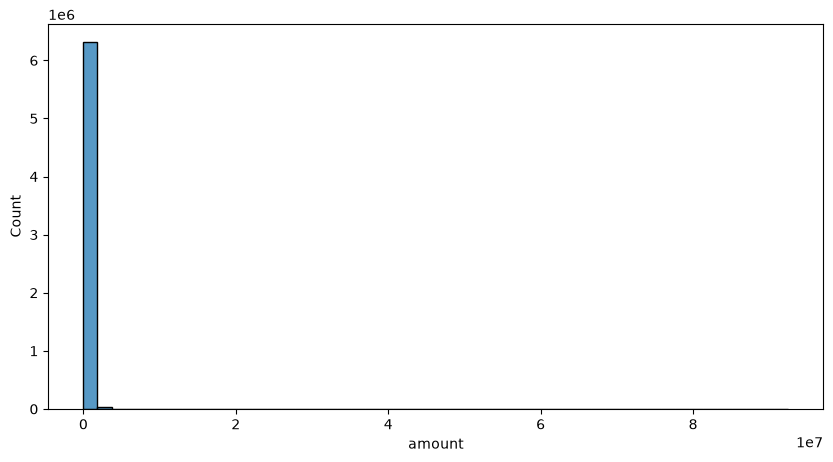

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["amount"],bins=50)

plt.show()

# Histogram

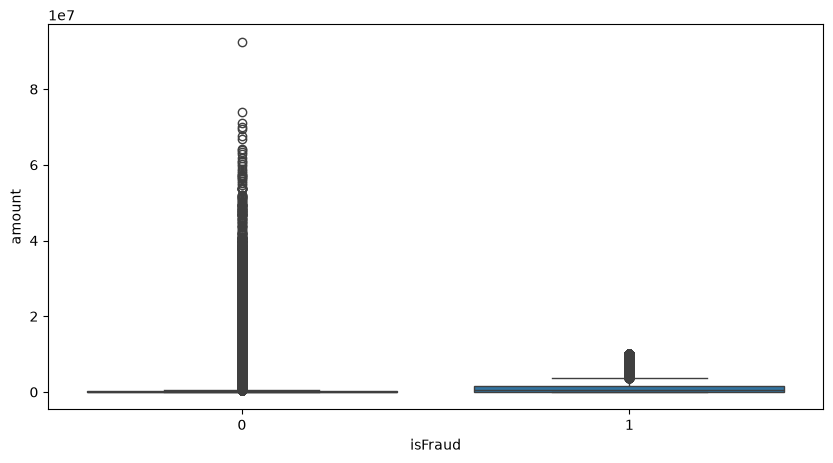

In [26]:
# Fraud and Non fraud amounts
plt.figure(figsize=(10,5))

sns.boxplot(
    x="isFraud",
    y="amount",
    data=df
)

plt.show()

In [27]:
df[[
"oldbalanceOrg",
"newbalanceOrig",
"oldbalanceDest",
"newbalanceDest"
]].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


In [34]:
# Correlation analysis
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()
corr["isFraud"].sort_values(
    ascending=False
)


isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

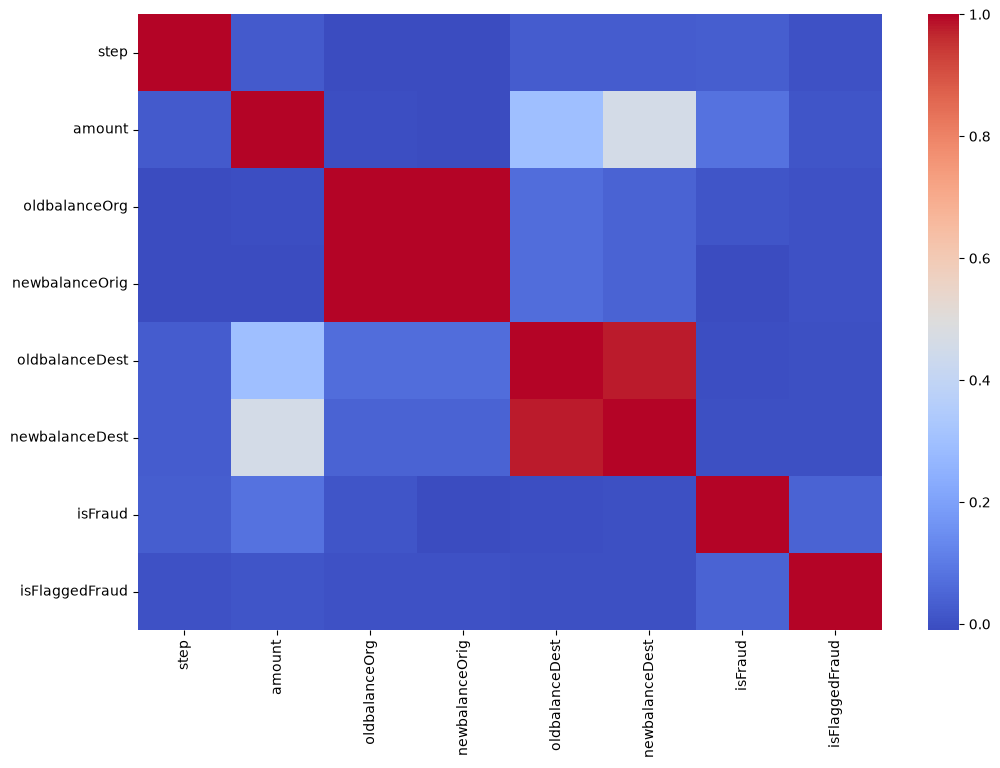

In [29]:
# HeatMap
plt.figure(figsize=(12,8))

sns.heatmap(corr,cmap="coolwarm")

plt.show()

In [31]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [32]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [33]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"]
)

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16
